In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure display settings
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)         # Don't wrap output
pd.set_option('display.max_rows', 100)       # Show more rows

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)    # Default figure size

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


In [2]:
# Cell 2: Load the dataset
# Adjust path based on where you saved the CSV
df = pd.read_csv('../data/raw/flight_data_2024.csv', parse_dates=['fl_date'])

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

C:\Users\davin\AppData\Local\Temp\ipykernel_9064\3524275120.py:3: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/flight_data_2024.csv', parse_dates=['fl_date'])


Dataset loaded: 7,079,081 rows × 35 columns
Memory usage: 4.23 GB


In [3]:
# Cell 3: First look at the data
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,DTW,"Detroit, MI",Michigan,1252,1247.0,-5.0,31.0,1318.0,1442.0,7.0,1508,1449.0,-19.0,0,NaN,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,CLE,"Cleveland, OH",Ohio,1015,1001.0,-14.0,20.0,1021.0,1249.0,6.0,1325,1255.0,-30.0,0,NaN,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,RIC,"Richmond, VA",Virginia,1415,1411.0,-4.0,21.0,1432.0,1533.0,8.0,1601,1541.0,-20.0,0,NaN,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,JFK,"New York, NY",New York,1650,1643.0,-7.0,13.0,1656.0,1747.0,12.0,1841,1759.0,-42.0,0,NaN,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,MKE,"Milwaukee, WI",Wisconsin,1015,1010.0,-5.0,21.0,1031.0,1016.0,4.0,1034,1020.0,-14.0,0,NaN,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [4]:
# Cell 4: Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype         
---  ------               -----         
 0   year                 int64         
 1   month                int64         
 2   day_of_month         int64         
 3   day_of_week          int64         
 4   fl_date              datetime64[ns]
 5   op_unique_carrier    object        
 6   op_carrier_fl_num    float64       
 7   origin               object        
 8   origin_city_name     object        
 9   origin_state_nm      object        
 10  dest                 object        
 11  dest_city_name       object        
 12  dest_state_nm        object        
 13  crs_dep_time         int64         
 14  dep_time             float64       
 15  dep_delay            float64       
 16  taxi_out             float64       
 17  wheels_off           float64       
 18  wheels_on            float64       
 19  taxi_in              

In [5]:
# Cell 5: Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Percentage': missing_pct.values
})

# Filter to only columns with missing data
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(
    'Missing_Count', 
    ascending=False
)

print("Columns with Missing Values:")
print("=" * 60)
print(missing_df.to_string(index=False))

Columns with Missing Values:
             Column  Missing_Count  Percentage
  cancellation_code        6982766   98.639442
           air_time         113814    1.607751
actual_elapsed_time         113814    1.607751
          arr_delay         113814    1.607751
          wheels_on          97856    1.382326
            taxi_in          97856    1.382326
           arr_time          97854    1.382298
         wheels_off          95734    1.352351
           taxi_out          95734    1.352351
          dep_delay          92970    1.313306
           dep_time          92659    1.308913
  op_carrier_fl_num              1    0.000014
   crs_elapsed_time              1    0.000014


In [6]:
# Cell 6: Analyze departure delay distribution
print("Departure Delay Statistics:")
print("=" * 60)
print(df['dep_delay'].describe())

print("\n" + "=" * 60)
print(f"Flights with data: {df['dep_delay'].notna().sum():,}")
print(f"Missing dep_delay: {df['dep_delay'].isna().sum():,}")
print(f"On-time or early (≤0 min): {(df['dep_delay'] <= 0).sum():,}")
print(f"Delayed >0 min: {(df['dep_delay'] > 0).sum():,}")
print(f"Delayed >15 min (DOT threshold): {(df['dep_delay'] > 15).sum():,}")
print(f"Severely delayed >60 min: {(df['dep_delay'] > 60).sum():,}")

Departure Delay Statistics:
count    6.986111e+06
mean     1.267708e+01
std      5.605997e+01
min     -9.600000e+01
25%     -6.000000e+00
50%     -2.000000e+00
75%      9.000000e+00
max      3.777000e+03
Name: dep_delay, dtype: float64

Flights with data: 6,986,111
Missing dep_delay: 92,970
On-time or early (≤0 min): 4,380,129
Delayed >0 min: 2,605,982
Delayed >15 min (DOT threshold): 1,397,084
Severely delayed >60 min: 508,227


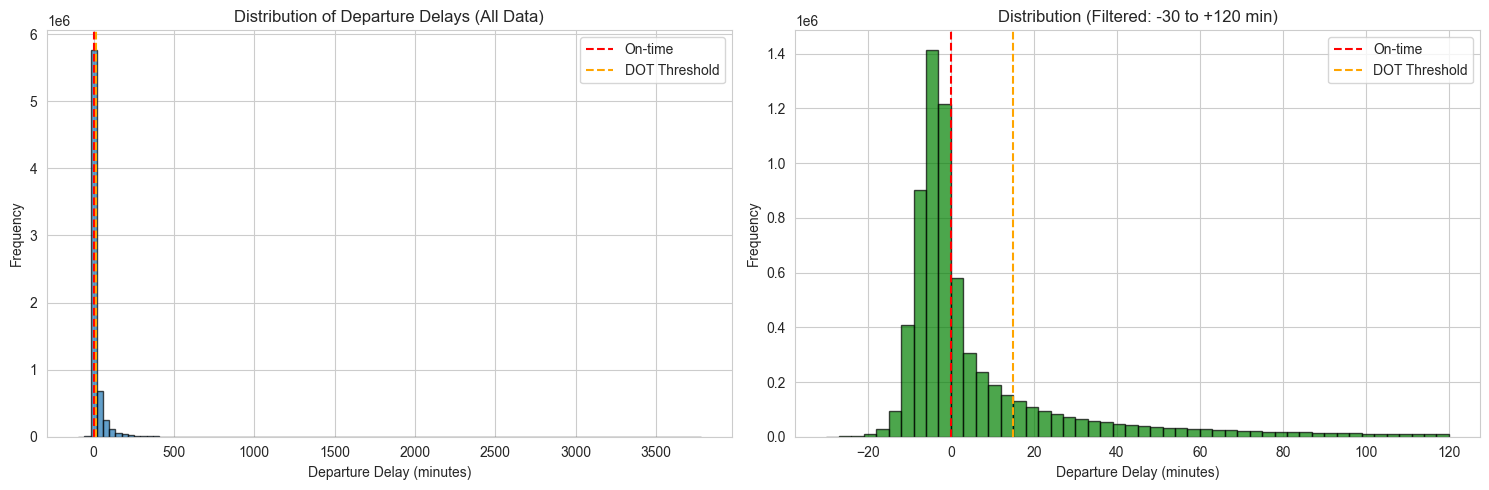

In [7]:
# Cell 7: Visualize delay distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Histogram of all delays
axes[0].hist(df['dep_delay'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Departure Delay (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Departure Delays (All Data)')
axes[0].axvline(x=0, color='red', linestyle='--', label='On-time')
axes[0].axvline(x=15, color='orange', linestyle='--', label='DOT Threshold')
axes[0].legend()

# Plot 2: Zoomed in to reasonable range (-30 to +120 minutes)
delay_filtered = df['dep_delay'].dropna()
delay_filtered = delay_filtered[(delay_filtered >= -30) & (delay_filtered <= 120)]

axes[1].hist(delay_filtered, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Departure Delay (minutes)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution (Filtered: -30 to +120 min)')
axes[1].axvline(x=0, color='red', linestyle='--', label='On-time')
axes[1].axvline(x=15, color='orange', linestyle='--', label='DOT Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

Average Delay by Day of Week:
                mean  median    count
Monday     12.732930    -2.0  1059709
Tuesday    10.461914    -3.0   964082
Wednesday  10.415932    -3.0   961589
Thursday   13.156098    -2.0  1027320
Friday     14.662691    -2.0  1039798
Saturday   12.589482    -2.0   900959
Sunday     14.393926    -2.0  1032654


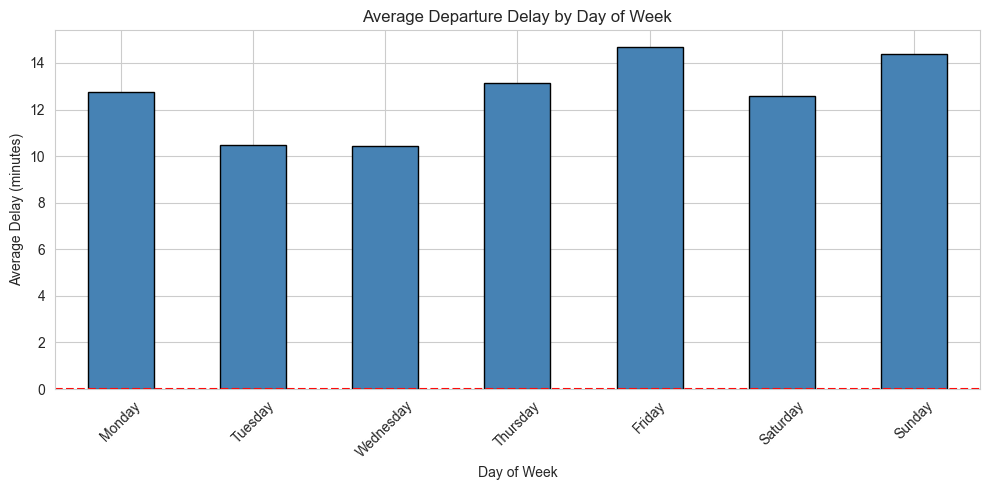

In [8]:
# Cell 8: Delays by day of week
delay_by_dow = df.groupby('day_of_week')['dep_delay'].agg(['mean', 'median', 'count'])
delay_by_dow.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

print("Average Delay by Day of Week:")
print("=" * 60)
print(delay_by_dow)

# Visualize
plt.figure(figsize=(10, 5))
delay_by_dow['mean'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (minutes)')
plt.title('Average Departure Delay by Day of Week')
plt.axhline(y=0, color='red', linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Final cell: Save cleaned data for feature engineering

# Apply cleaning
df_clean = df[df['cancelled'] == 0].copy()
df_clean = df_clean[df_clean['dep_delay'].notna()].copy()

# Create target variable
df_clean['is_delayed'] = (df['dep_delay'] > 15).astype(int)

# Save
output_path = '../data/processed/cleaned_flights.csv'
df_clean.to_csv(output_path, index=False)

print(f"✓ Saved {len(df_clean):,} flights to {output_path}")
print(f"✓ File size: {df_clean.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("\nReady for feature engineering in notebook 02!")

✓ Saved 6,982,766 flights to ../data/processed/cleaned_flights.csv
✓ File size: 4378.6 MB

Ready for feature engineering in notebook 02!
